In [1]:
from fastai.vision.all import *
from make import load_secondary_data
from pathlib import Path
import os

In [2]:
spec, label = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [3]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [4]:
def get_x(i):
    arr = spec[i]  # (H, W) or (H, W, C)

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

<Axes: >

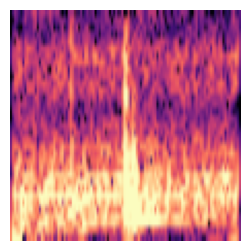

In [13]:
get_x(5).show()

In [5]:
torch.save(get_x(5), 'test_tensor.pt')

In [6]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=spec)

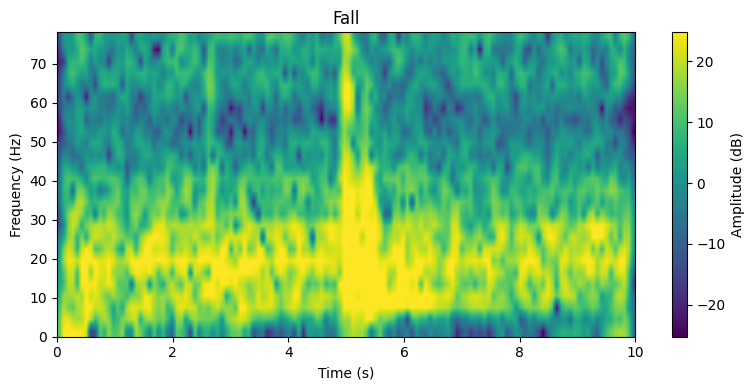

In [7]:
plotUtil.show_spec(5, "Fall")